# Loss Functions and Regularization

## 📚 Learning Objectives

By completing this notebook, you will:
- Define and implement common loss functions
- Choose losses for regression vs classification
- Connect losses to model training

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — you implemented MSE there; here we add the classification losses and the penalties that regularize them.

**Used later in:** Course 08 (AIAT 122) — Unit 1 — `CrossEntropyLoss()` and `compile(loss=...)` pick from exactly this list.

---


---

## 📌 Real case: the year object detection was fixed by changing the loss

Until 2017 there was a stubborn gap in computer vision: fast **one-stage** object detectors were less
accurate than slow **two-stage** ones, and nobody could close it with better architectures. Tsung-Yi Lin,
Priya Goyal, Ross Girshick, Kaiming He and Piotr Dollár diagnosed the cause in *"Focal Loss for Dense
Object Detection"* (ICCV 2017): a dense detector scores an enormous number of candidate boxes per image,
and almost all of them are obviously empty background. Summing ordinary cross-entropy over them means, in
their words, that "the vast number of easy negatives" overwhelms the handful of examples that actually
matter — the loss is dominated by boxes the model already gets right.

Their fix changed neither the architecture nor the data. They **reshaped the loss function**, adding a
factor that down-weights well-classified examples so training concentrates on the hard ones. The resulting
detector, RetinaNet, matched the speed of one-stage detectors and beat the accuracy of the two-stage
state of the art.

**What goes wrong without this.** The loss is not a scoring formality — it is the definition of what your
model is trying to do. Choose it carelessly and gradient descent will faithfully optimise the wrong thing,
at full speed, with a beautifully falling training curve.

**The same reasoning appears elsewhere:** fraud detection, where 0.2% of transactions are fraudulent;
rare-disease screening; keyword spotting. Whenever the interesting class is rare, the default loss quietly
optimises for ignoring it.


# Loss Functions and Regularization

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Optimizers** - Understand how optimizers work
- ✅ **Module 02: Calculus** - Understand derivatives
- ✅ **Basic understanding**: What is a loss function?

**If you haven't completed these**, you might struggle with:
- Understanding different loss functions
- Understanding regularization

---

## 🔗 Where This Notebook Fits

**This is the SECOND example of Module 03** - what optimizers minimize!

**Why this example SECOND?**
- **Before** you can understand loss functions, you need optimizers (Example 1)
- **Before** you can train models, you need to define what to minimize

**Builds on**: Example 1 (optimizers)

**Leads to**: Example 3: Statistical Measures

---

## The Story: Understanding Before Using

Imagine you're training for a race. **Before** you can train effectively, you need to know what you're optimizing for. **After** understanding loss functions, you know exactly what your model is trying to minimize!

Same with machine learning: **Before** training models, we need to define what "good" means. **After** understanding loss functions, we know exactly what to minimize!

---

## Why This Concept Matters

### Why Loss Functions Matter in ML

**WHY** are loss functions essential?

1. **Define Objective**:
   - **WHY**: Need to know what "good" means
   - **HOW**: Loss function quantifies error
   - **AFTER**: Clear optimization target

2. **Different Problems, Different Losses**:
   - **WHY**: Classification vs regression need different losses
   - **HOW**: MSE for regression, cross-entropy for classification
   - **AFTER**: Better model performance

## Learning Objectives
1. Understand different loss functions (MSE, MAE)
2. Understand regularization (L1, L2)
3. Choose the right loss function
4. Visualize loss functions

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this works in ML!

## Step 2: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

In [2]:
# Example 1: Loss Functions
# WHY: Need to measure how wrong predictions are
# HOW: Compute error between predictions and targets

def mse_loss(predictions, targets):
    """Mean Squared Error"""
    return np.mean((predictions - targets)**2)

def mae_loss(predictions, targets):
    """Mean Absolute Error"""
    return np.mean(np.abs(predictions - targets))

predictions = np.array([2.1, 3.2, 4.0, 5.1])
targets = np.array([2.0, 3.0, 4.0, 5.0])

print("Example 1: Loss Functions")
print("=" * 60)
print(f"Predictions: {predictions}")
print(f"Targets:    {targets}")
print(f"\nMSE: {mse_loss(predictions, targets):.4f}")
print(f"  💡 WHY: Penalizes large errors more")
print(f"  💡 HOW: Square errors, then average")
print(f"\nMAE: {mae_loss(predictions, targets):.4f}")
print(f"  💡 WHY: Treats all errors equally")
print(f"  💡 HOW: Take absolute value, then average")

Example 1: Loss Functions
Predictions: [2.1 3.2 4.  5.1]
Targets:    [2. 3. 4. 5.]

MSE: 0.0150
  💡 WHY: Penalizes large errors more
  💡 HOW: Square errors, then average

MAE: 0.1000
  💡 WHY: Treats all errors equally
  💡 HOW: Take absolute value, then average


### 🧪 What happens to each loss when *one* record goes wrong?

Baseline: the four predictions above, all close to their targets. Change one thing: corrupt a single
target — one mislabelled record out of four, the sort of thing a typo produces. Measure how far each loss
moves, and what each one would then recommend as a single best guess.

In [3]:
# Comparative experiment: MSE and MAE under one corrupted label.

targets_bad = targets.copy()
targets_bad[2] = 14.0          # was 4.0 - one bad record out of four

mse_clean, mae_clean = mse_loss(predictions, targets), mae_loss(predictions, targets)
mse_bad, mae_bad = mse_loss(predictions, targets_bad), mae_loss(predictions, targets_bad)

print(f"{'':26}{'MSE':>12}{'MAE':>12}")
print("-" * 50)
print(f"{'clean targets':26}{mse_clean:12.4f}{mae_clean:12.4f}")
print(f"{'one corrupted target':26}{mse_bad:12.4f}{mae_bad:12.4f}")
print(f"{'multiplied by':26}{mse_bad / mse_clean:11.0f}x{mae_bad / mae_clean:11.0f}x")
print()
print("And what each loss would recommend as a single best constant prediction:")
print(f"   minimising MSE picks the MEAN   of the corrupted targets = {targets_bad.mean():.2f}")
print(f"   minimising MAE picks the MEDIAN of the corrupted targets = {np.median(targets_bad):.2f}")
print(f"   (the three untouched targets are {targets[targets != targets[2]]})")
print()
print("Conclusion the numbers support: squaring multiplied the effect of ONE bad record far more")
print("than the absolute error did, and it dragged the recommended prediction away from every")
print("clean point. MSE is right when a large error really is disproportionately costly (a")
print("mis-dosed drug). It is wrong when a large error usually means 'someone mistyped', because")
print("then you have handed the model over to the typo. Huber's 1964 loss is the compromise:")
print("squared near zero, linear far out - see this notebook's reference list.")

                                   MSE         MAE
--------------------------------------------------
clean targets                   0.0150      0.1000
one corrupted target           25.0150      2.6000
multiplied by                    1668x         26x

And what each loss would recommend as a single best constant prediction:
   minimising MSE picks the MEAN   of the corrupted targets = 6.00
   minimising MAE picks the MEDIAN of the corrupted targets = 4.00
   (the three untouched targets are [2. 3. 5.])

Conclusion the numbers support: squaring multiplied the effect of ONE bad record far more
than the absolute error did, and it dragged the recommended prediction away from every
clean point. MSE is right when a large error really is disproportionately costly (a
mis-dosed drug). It is wrong when a large error usually means 'someone mistyped', because
then you have handed the model over to the typo. Huber's 1964 loss is the compromise:
squared near zero, linear far out - see this notebo

## Step 3: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

In [4]:
# Example 2: Regularization
# WHY: Prevent overfitting
# HOW: Add penalty term to loss

def loss_with_l2_regularization(predictions, targets, weights, lambda_reg=0.1):
    """Loss with L2 regularization"""
    mse = mse_loss(predictions, targets)
    l2_penalty = lambda_reg * np.sum(weights**2)
    return mse + l2_penalty

weights = np.array([0.5, 0.3, 0.2])
loss_with_reg = loss_with_l2_regularization(predictions, targets, weights)
loss_without_reg = mse_loss(predictions, targets)

print("\nExample 2: Regularization")
print("=" * 60)
print(f"Loss without regularization: {loss_without_reg:.4f}")
print(f"Loss with L2 regularization: {loss_with_reg:.4f}")
print(f"\n💡 WHY: Prevents overfitting by penalizing large weights")
print(f"💡 HOW: Add λ × sum(weights²) to loss")
print(f"💡 AFTER: Simpler, more generalizable models!")


Example 2: Regularization
Loss without regularization: 0.0150
Loss with L2 regularization: 0.0530

💡 WHY: Prevents overfitting by penalizing large weights
💡 HOW: Add λ × sum(weights²) to loss
💡 AFTER: Simpler, more generalizable models!


---

## 📊 Visualization

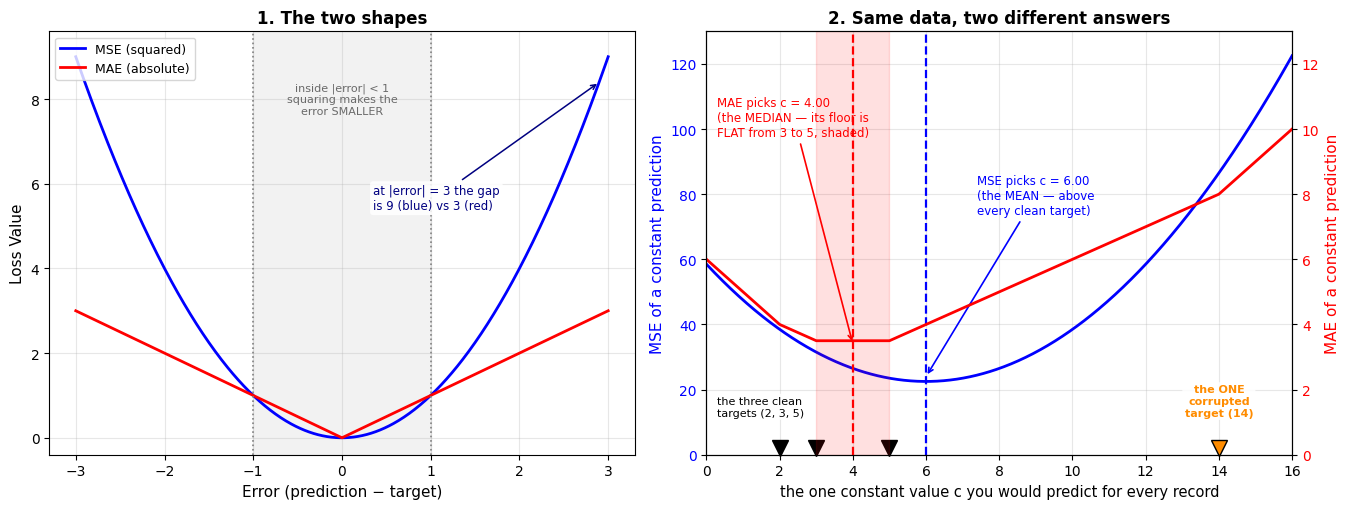


📊 Reading the figure:
  Panel 1: at |error| = 0.5 squaring gives 0.25 vs 0.50 — SMALLER.
           at |error| = 3.0 squaring gives 9.00 vs 3.00 — 3x LARGER.
  Panel 2: on targets [2.0, 3.0, 14.0, 5.0], the two losses choose different answers.
           MSE bottoms out at c = 6.00 (loss 22.50).
           MAE bottoms out anywhere in [3.00, 5.00] (loss 3.50); the median, 4.00, is the usual choice.
  The clean targets are [2.0, 3.0, 5.0]. MSE's answer, 6.00, is above ALL of them —
  one corrupted record out of four dragged it there. MAE's answer sits among them.


In [5]:
# Why this matters: the loss's SHAPE decides what the model fears — squaring makes big errors dominate.
# VISUAL: left, the two shapes. Right, the CONSEQUENCE on this notebook's own corrupted
# data — the single number each loss would pick if it had to guess one value for everything.

# Visualize loss functions
x_range = np.linspace(-3, 3, 601)
errors = x_range
# MSE grows quadratically; MAE linearly — compute both on the same error range.
mse_values = errors**2
mae_values = np.abs(errors)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.6, 5.2))

# --- left: the shapes, and the error size where squaring takes over ---------------
ax.plot(errors, mse_values, 'b-', linewidth=2, label='MSE (squared)')
ax.plot(errors, mae_values, 'r-', linewidth=2, label='MAE (absolute)')
# WHY mark |error| = 1: below it, squaring SHRINKS an error (0.5² = 0.25); above it,
# squaring MAGNIFIES it (3² = 9). That crossover is the whole behavioural difference.
for xc in (-1, 1):
    ax.axvline(xc, color='grey', ls=':', lw=1.2)
ax.axvspan(-1, 1, color='grey', alpha=0.10)
ax.text(0, 8.4, 'inside |error| < 1\nsquaring makes the\nerror SMALLER',
        fontsize=8, ha='center', va='top', color='dimgrey')
ax.annotate('at |error| = 3 the gap\nis 9 (blue) vs 3 (red)', xy=(2.9, 8.4), xytext=(0.35, 5.4),
            fontsize=8.5, color='navy',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85),
            arrowprops=dict(arrowstyle='->', color='navy', lw=1.1))
ax.set_xlabel('Error (prediction − target)', fontsize=11)
ax.set_ylabel('Loss Value', fontsize=11)
ax.set_title('1. The two shapes', fontsize=12, fontweight='bold')
ax.set_ylim(-0.4, 9.6)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# --- right: what each loss CHOOSES on the corrupted data from the cell above -------
# WHAT: sweep one constant prediction c across the whole range and score it with each
# loss against `targets_bad` = [2, 3, 14, 5]. WHY: the loss that "wins" is not an
# abstraction — it is whichever c each curve bottoms out at, and they disagree.
c_sweep = np.linspace(0, 16, 801)
mse_curve = np.mean((c_sweep[:, None] - targets_bad) ** 2, axis=1)
mae_curve = np.mean(np.abs(c_sweep[:, None] - targets_bad), axis=1)
c_mse = float(c_sweep[mse_curve.argmin()])            # = the mean
flat = c_sweep[mae_curve <= mae_curve.min() + 1e-9]   # MAE's floor is an INTERVAL here
c_mae = float(np.median(targets_bad))

ax2.plot(c_sweep, mse_curve, 'b-', lw=2, label='mean squared error')
ax2.set_ylabel('MSE of a constant prediction', color='blue', fontsize=11)
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axvline(c_mse, color='blue', ls='--', lw=1.6)
ax2.set_xlabel('the one constant value c you would predict for every record', fontsize=10.5)
ax2.set_title('2. Same data, two different answers', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 130)   # tall enough that the blue parabola never leaves the frame

ax2r = ax2.twinx()
ax2r.plot(c_sweep, mae_curve, 'r-', lw=2, label='mean absolute error')
ax2r.set_ylabel('MAE of a constant prediction', color='red', fontsize=11)
ax2r.tick_params(axis='y', labelcolor='red')
ax2r.set_ylim(0, 13)
# The MAE floor is flat from 3 to 5 — shade it rather than pretend the minimum is a point.
ax2r.axvspan(flat.min(), flat.max(), color='red', alpha=0.12)
ax2r.axvline(c_mae, color='red', ls='--', lw=1.6)

# The four targets themselves, as ticks along the bottom: three clean, one corrupted.
for t in targets_bad:
    is_bad = t == 14.0
    ax2.plot([t], [2.0], marker='v', ms=11,
             color='black' if not is_bad else 'darkorange',
             markeredgecolor='black', clip_on=False, zorder=6)
ax2.text(14.0, 12.0, 'the ONE\ncorrupted\ntarget (14)', fontsize=8, ha='center',
         color='darkorange', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85))
ax2.text(0.3, 12.0, 'the three clean\ntargets (2, 3, 5)', fontsize=8, ha='left',
         bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85))
ax2.annotate(f'MSE picks c = {c_mse:.2f}\n(the MEAN — above\nevery clean target)',
             xy=(c_mse, 24), xytext=(7.4, 74), fontsize=8.5, color='blue',
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.2))
ax2.annotate(f'MAE picks c = {c_mae:.2f}\n(the MEDIAN — its floor is\nFLAT from 3 to 5, shaded)',
             xy=(c_mae, 34), xytext=(0.3, 98), fontsize=8.5, color='red',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 16)

plt.tight_layout()
plt.show()

print("\n📊 Reading the figure:")
print("=" * 70)
print(f"  Panel 1: at |error| = 0.5 squaring gives {0.5**2:.2f} vs {0.5:.2f} — SMALLER.")
print(f"           at |error| = 3.0 squaring gives {3.0**2:.2f} vs {3.0:.2f} — 3x LARGER.")
print(f"  Panel 2: on targets {targets_bad.tolist()}, the two losses choose different answers.")
print(f"           MSE bottoms out at c = {c_mse:.2f} (loss {mse_curve.min():.2f}).")
print(f"           MAE bottoms out anywhere in [{flat.min():.2f}, {flat.max():.2f}] "
      f"(loss {mae_curve.min():.2f}); the median, {c_mae:.2f}, is the usual choice.")
print(f"  The clean targets are {targets[targets != targets[2]].tolist()}. MSE's answer, "
      f"{c_mse:.2f}, is above ALL of them —")
print("  one corrupted record out of four dragged it there. MAE's answer sits among them.")

### 📊 What to see in the figure above

**Panel 1 — the two shapes, and where they swap roles.** The grey band marks `|error| < 1`.
*Inside* it the blue MSE curve lies **below** the red MAE line: squaring an error smaller
than 1 makes it smaller still (0.5² = 0.25), so MSE barely notices near-misses. *Outside*
it the blue curve rises above the red one and keeps pulling away — at `|error| = 3` the
arrowed point reads **9 for MSE against 3 for MAE**. The two curves touch at exactly
`error = ±1` and at `0`. That crossover is the whole behavioural difference between the
losses: MSE spends its attention on the far-out points, MAE spreads it evenly.

**Panel 2 — the same disagreement, on this notebook's own corrupted data.** The x-axis
sweeps one constant prediction `c` for all four records; the blue curve (left axis) scores
that `c` with MSE and the red curve (right axis) scores it with MAE, against
`targets_bad = [2, 3, 14, 5]`. The black triangles on the floor are the three clean targets
`2, 3, 5`; the orange triangle at `14` is the single corrupted record. Now look at where
each curve bottoms out. **The blue curve has one sharp minimum at `c = 6.00`** (blue dashed
line) — the mean, and it sits to the *right of every clean target*. **The red curve's floor
is flat across the pink band from 3 to 5** — for MAE, any constant in that range is equally
good, and the conventional pick is the median, `c = 4.00` (red dashed line), which sits
among the clean targets.

One mistyped record out of four moved MSE's answer clean off the data. That is the
`1668×` in the table above, drawn.

---

## ⚠️ Where this breaks

- **MSE assumes your large errors are real.** The experiment above shows a single corrupted label moving
  MSE by orders of magnitude more than MAE, and pulling the best constant prediction away from every clean
  point. That sensitivity is a *feature* when large errors are genuinely catastrophic and a *bug* when
  large errors are data-entry mistakes. The assumption that must hold: your outliers are signal, not noise.
- **Regularization strength is not comparable across problems.** The λ = 0.1 above adds 0.038 to a loss of
  0.015 — the penalty is more than twice the fit term, which for a real model would mean the weights are
  being driven to zero regardless of the data. λ has to be tuned against *your* loss scale and *your*
  feature scaling, by cross-validation, not copied from a tutorial. Unit 1, notebook 08 sweeps it on real
  data and finds the improvement is worth 0.008 of R².
- **The loss you can differentiate is not the loss you care about.** You optimise MSE or cross-entropy;
  the business cares about money, or a radiologist's time, or a false-negative that reaches a patient.
  Focal loss exists because that gap was costing accuracy. Before choosing a loss, write down the real
  cost of each kind of mistake — and if the costs are asymmetric, say so in the loss (weighted classes,
  quantile regression) rather than hoping the metric notices.


---

## 💬 Discuss

1. One corrupted record out of four moved MSE far more than MAE. A colleague concludes "so always use MAE."
   Give a concrete scenario from healthcare or finance where that advice would be dangerous, and say what
   you would use instead.
2. Lin and colleagues improved object detection by changing the loss rather than the model. What does that
   suggest about where you should look first when a model underperforms — and why do you think most
   practitioners reach for the architecture instead?
3. You are building a model to predict electricity demand for a Saudi utility. Being 500 MW *under* causes
   blackouts; being 500 MW *over* wastes fuel. Neither MSE nor MAE knows the difference. Propose a loss
   that does, and say what you would need from the utility to specify it.


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding loss functions:

1. **Model Training**: Can define what to optimize
2. **Better Performance**: Can choose right loss for problem
3. **Regularization**: Can prevent overfitting
4. **Next Steps**: Learn statistical measures (Example 3)

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand this concept.

**AFTER this notebook**: We understand WHY, HOW, and AFTER!

---

## ✅ Example Complete!

## 📚 References

1. Huber, P. J. (1964). *Robust Estimation of a Location Parameter*. The Annals of Mathematical Statistics, 35(1), 73–101.
2. Terven, J., Cordova-Esparza, D. M., Ramirez-Pedraza, A., Chavez-Urbiola, E. A., & Romero-Gonzalez, J. A. (2023). *Loss Functions and Metrics in Deep Learning*. arXiv. <https://arxiv.org/abs/2307.02694>
3. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Ch. 1: Introduction. Springer.
4. Rafailov et al. (2023). *Direct Preference Optimization: Your Language Model is Secretly a Reward Model*. arXiv. <https://arxiv.org/abs/2305.18290> — a loss function, not a new algorithm, is what removed the reward model from alignment.
5. Shao et al. (2024). *DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models*. arXiv. <https://arxiv.org/abs/2402.03300> — GRPO: the loss behind most 2025-26 reasoning training, and a worked example of designing one.
